to do


In [1]:
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.colors
import itertools

In [2]:
file = '~/Desktop/aggie nova/galaxy project/eazy-photoz/FinalPhotUV.dat'
df= pd.read_csv(file, sep='\s+')

Kfile = '~/Desktop/aggie nova/galaxy project/eazy-photoz/BLAST/KcorrectedFinalPhotUV.csv'
K_df= pd.read_csv(Kfile, sep=',')

SNfile = '~/Desktop/aggie nova/galaxy project/eazy-photoz/BLAST/outputmags_color.dat'
SN_df= pd.read_csv(SNfile, sep='\s+')


df, K_df, SN_df

(              sn    UVW2  errUVW2    UVM2  errUVM2    UVW1  errUVW1       U  \
 0      SN2016eii  16.433    0.042  16.447    0.058  16.498    0.053  16.525   
 1       SN2010ev  13.324    0.039  13.332    0.040  12.906    0.039  12.468   
 2      SN2016eja  17.181    0.057  17.295    0.074  17.116    0.075  16.576   
 3       SN2010jn  14.207    0.037  14.242    0.037  14.169    0.043  13.891   
 4    ASASSN-13ch  16.210    0.050  16.299    0.048  16.231    0.066  16.123   
 ..           ...     ...      ...     ...      ...     ...      ...     ...   
 122     SN2010gp  14.806    0.033  14.791    0.037  14.259    0.034  13.344   
 123     SN2012bl  15.393    0.043  15.419    0.043  15.024    0.047  14.724   
 124  ASASSN-13dd  16.200    0.064  16.271    0.075  14.877    0.042  13.495   
 125    SN2016ekt  16.917    0.044  16.872    0.054  16.914    0.054  16.751   
 126     SN2010kg  15.455    0.035  15.545    0.035  15.107    0.035  14.271   
 
       errU       B    errB       V   

In [3]:
#for og df
UVW2 = df.loc[:,'UVW2']
UVW1 = df.loc[:,'UVW1']
UVM2 = df.loc[:, 'UVM2']
B = df.loc[:, 'B']
V = df.loc[:,'V']

errUVW2 = df.loc[:,'errUVW2']
errUVW1 = df.loc[:,'errUVW1']
errUVM2 = df.loc[:, 'errUVM2']
errB = df.loc[:, 'errB']
errV = df.loc[:,'errV']


#for Kdf
K_UVW2 = K_df.loc[:,'K_UVW2']
K_UVW1 = K_df.loc[:,'K_UVW1']
K_UVM2 = K_df.loc[:, 'K_UVM2']
K_B = K_df.loc[:, 'K_B']
K_V = K_df.loc[:,'K_V']

Kerr_UVW2 = K_df.loc[:,'Kerr_UVW2']
Kerr_UVW1 = K_df.loc[:,'Kerr_UVW1']
Kerr_UVM2 = K_df.loc[:, 'Kerr_UVM2']
Kerr_B = K_df.loc[:, 'Kerr_B']
Kerr_V = K_df.loc[:,'Kerr_V']

#for SNdf
SN_UVW2 = SN_df.loc[:,'SN_UVW2']
SN_UVW1 = SN_df.loc[:,'SN_UVW1']
SN_UVM2 = SN_df.loc[:, 'SN_UVM2']
SN_B = SN_df.loc[:, 'SN_B']
SN_V = SN_df.loc[:,'SN_V']



In [ ]:
#sn with large errors = SN2010ih,SN2006E,SN2011dm,ASASSN-14lw,SN2014ai,ASASSN-15hx,ASASSN-13dd 

In [7]:
# kcorrected v - finding the bluest + reddest gals
df['UVW1_minus_V'] = df['UVW1'] - df['V']
df['B_minus_V'] = df['B'] - df['V']

K_df['K_UVW1_minus_V'] = K_df['K_UVW1'] - K_df['K_V']
K_df['K_B_minus_V'] = K_df['K_B'] - K_df['K_V']

SN_df['SN_UVW1_minus_V'] = SN_df['SN_UVW1'] - SN_df['SN_V']
SN_df['SN_B_minus_V'] = SN_df['SN_B'] - SN_df['SN_V']

print("Bluest galaxy:")
print(df.loc[df['sn'] == 'SN2011aa', ['sn', 'UVW1_minus_V', 'B_minus_V']])
print(K_df.loc[K_df['sn'] == 'SN2011aa', ['sn', 'K_UVW1_minus_V', 'K_B_minus_V']])
print(SN_df.loc[SN_df['sn'] == 'SN2011aa', ['sn', 'SN_UVW1_minus_V', 'SN_B_minus_V']])

print("Reddest galaxy:")
print(df.loc[74, ['sn', 'UVW1_minus_V', 'B_minus_V']])
print(K_df.loc[K_df['sn'] == 'SN2011B', ['sn', 'K_UVW1_minus_V', 'K_B_minus_V']])
print(SN_df.loc[SN_df['sn'] == 'SN2011B', ['sn', 'SN_UVW1_minus_V', 'SN_B_minus_V']])

Bluest galaxy:
          sn  UVW1_minus_V  B_minus_V
16  SN2011aa        -0.067      0.358
          sn  K_UVW1_minus_V  K_B_minus_V
16  SN2011aa          -0.067        0.358
          sn  SN_UVW1_minus_V  SN_B_minus_V
22  SN2011aa        -0.161155     -0.125453
Reddest galaxy:
sn              SN2011B
UVW1_minus_V       3.11
B_minus_V         0.702
Name: 74, dtype: object
         sn  K_UVW1_minus_V  K_B_minus_V
74  SN2011B            3.11        0.702
         sn  SN_UVW1_minus_V  SN_B_minus_V
23  SN2011B          1.13881     -0.086289


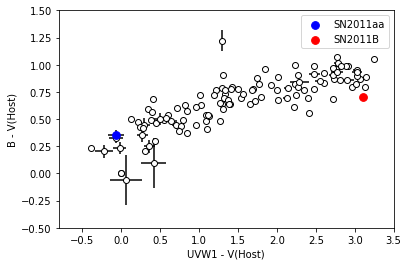

In [6]:
#for fig 3a
x1 = UVW1-V
y1 = B-V
x1err = abs(errUVW1-errV)
y1err = abs(errB-errV)

#reasonable error bars
good_xerr = x1err < 5
good_yerr = y1err < 5
good_mask = good_xerr & good_yerr

x1_good = x1[good_mask]
y1_good = y1[good_mask]
x1err_good = x1err[good_mask]
y1err_good = y1err[good_mask]

#plot
plt.figure()
plt.tight_layout()
plt.xlabel('UVW1 - V(Host)')
plt.ylabel('B - V(Host)')
#plt.scatter(K_x1,K_y1, color='green')
plt.errorbar(x1_good,y1_good, xerr=x1err_good, yerr=y1err_good, fmt='o', ecolor='k', mfc='white',mec='k')
#bad_mask = ~good_mask
#plt.scatter(x1[bad_mask], y1[bad_mask], color='red', marker='x', label='Bad errors')
plt.xlim(-.8,3.5)
plt.ylim(-0.5,1.5)
plt.scatter(x=-0.067, y=0.358, color='blue', s=60, zorder=10, label='SN2011aa')
plt.scatter(x=3.11, y=0.702, color='red', s=60, zorder=10, label='SN2011B')

plt.legend()
plt.savefig('3a')
plt.show()
plt.close()

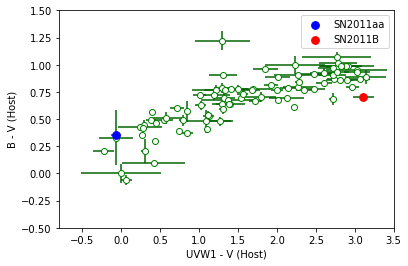

In [8]:
#remake with new df
#with Kcorrected ones
K_x1 = K_UVW1-K_V
K_y1 = K_B-K_V
K_x1err = abs(Kerr_UVW1-Kerr_V)
K_y1err = abs(Kerr_B-Kerr_V)

#with the sn phot
SN_x1 = SN_UVW1-SN_V
SN_y1 = SN_B-SN_V

#plot
plt.figure()
plt.tight_layout()
plt.xlabel('UVW1 - V (Host)')
plt.ylabel('B - V (Host)')
plt.errorbar(K_x1,K_y1, xerr=K_x1err, yerr=K_y1err, fmt='o', ecolor='darkgreen', mfc='white',mec='green')
#plt.errorbar(SN_x1,SN_y1, fmt='x', ecolor='purple', mfc='purple',mec='purple')
#plt.errorbar(x1_good,y1_good, xerr=x1err_good, yerr=y1err_good, fmt='o', ecolor='k', mfc='white',mec='k')
plt.xlim(-.8,3.5)
plt.ylim(-0.5,1.5)
plt.scatter(x=-0.067, y=0.358, color='blue', s=60, zorder=10, label='SN2011aa')
#plt.scatter(x=-0.188881, y=-0.111103, marker='x', color='blue', s=60, zorder=10, label='SN2011aa')
plt.scatter(x=3.11, y=0.702, color='red', s=60, zorder=10, label='SN2011B')
#plt.scatter(x=0.878663, y=-0.033755, marker='x', color='red', s=60, zorder=10, label='SN2011B')
plt.legend()

plt.savefig('K_3a')
plt.show()
plt.close()

In [21]:
#finding the bluest + reddest gals
df['UVW1_minus_V'] = df['UVW1'] - df['V']
df['B_minus_V'] = df['B'] - df['V']

# kcorrected v - finding the bluest + reddest gals
df['UVW1_minus_UVM2'] =  df['UVM2']-df['UVW1']
df['B_minus_V'] = df['B'] - df['V']

K_df['K_UVW1_minus_UVM2'] = K_df['K_UVM2']-K_df['K_UVW1']
K_df['K_B_minus_V'] = K_df['K_B'] - K_df['K_V']

SN_df['SN_UVW1_minus_UVM2'] = SN_df['SN_UVM2']-SN_df['SN_UVW1'] 
SN_df['SN_B_minus_V'] = SN_df['SN_B'] - SN_df['SN_V']

print(" Bluest galaxy:")
print(df.loc[df['sn'] == 'SN2011aa', ['sn', 'UVW1_minus_UVM2', 'B_minus_V']])
print(K_df.loc[K_df['sn'] == 'SN2011aa', ['sn', 'K_UVW1_minus_UVM2', 'K_B_minus_V']])
print(SN_df.loc[SN_df['sn'] == 'SN2011aa', ['sn', 'SN_UVW1_minus_UVM2', 'SN_B_minus_V']])

print(" Reddest galaxy:")
print(df.loc[df['sn'] == 'SN2011B', ['sn', 'UVW1_minus_UVM2', 'B_minus_V']])
print(K_df.loc[K_df['sn'] == 'SN2011B', ['sn', 'K_UVW1_minus_UVM2', 'K_B_minus_V']])
print(SN_df.loc[SN_df['sn'] == 'SN2011B', ['sn', 'SN_UVW1_minus_UVM2', 'SN_B_minus_V']])


 Bluest galaxy:
          sn  UVW1_minus_UVM2  B_minus_V
16  SN2011aa           -0.088      0.358
          sn  K_UVW1_minus_UVM2  K_B_minus_V
16  SN2011aa             -0.088        0.358
          sn  SN_UVW1_minus_UVM2  SN_B_minus_V
22  SN2011aa            0.548351     -0.125453
 Reddest galaxy:
         sn  UVW1_minus_UVM2  B_minus_V
74  SN2011B            1.166      0.702
         sn  K_UVW1_minus_UVM2  K_B_minus_V
74  SN2011B              1.166        0.702
         sn  SN_UVW1_minus_UVM2  SN_B_minus_V
23  SN2011B            1.844813     -0.086289


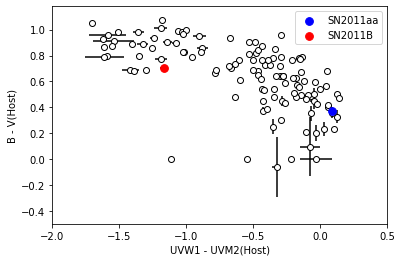

In [24]:
#for fig 3b
x2 = UVW1-UVM2
y2 = B-V
x2err = abs(errUVW1-errUVM2)
y2err = abs(errB-errV)

#reasonable error bars
good_x2err = x2err < 5
good_y2err = y2err < 5
good_mask2 = good_x2err & good_y2err

x2_good = x2[good_mask2]
y2_good = y2[good_mask2]
x2err_good = x2err[good_mask2]
y2err_good = y2err[good_mask2]

#plot
plt.figure()
plt.tight_layout()
plt.xlabel('UVW1 - UVM2(Host)')
plt.ylabel('B - V(Host)')
#plt.scatter(x2,y)
#plt.errorbar(x2,y2, xerr=x2err, yerr=y2err, fmt='o', ecolor='red', mfc='white',mec='k')
plt.errorbar(x2_good,y2_good, xerr=x2err_good, yerr=y2err_good, fmt='o', ecolor='k', mfc='white',mec='k')
plt.xlim(-2,0.5)
plt.ylim(-0.5,1.18)
plt.scatter(x=0.088 , y=0.368, color='blue', s=60, zorder=10, label='SN2011aa')
plt.scatter(x=-1.166, y=0.702, color='red', s=60, zorder=10, label='SN2011B')

plt.legend()
plt.savefig('3b')
plt.show()
plt.close()

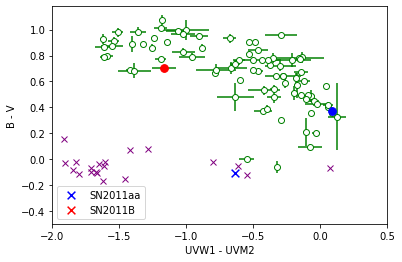

In [25]:
#remake with new df
#with Kcorrected ones
K_x2 = K_UVW1-K_UVM2
K_y2 = K_B-K_V
K_x2err = abs(Kerr_UVW1-Kerr_UVM2)
K_y2err = abs(Kerr_B-Kerr_V)

#sn
SN_x2 = SN_UVW1-SN_UVM2
SN_y2 = SN_B-SN_V

#plot
plt.figure()
plt.tight_layout()
plt.xlabel('UVW1 - UVM2')
plt.ylabel('B - V')
#plt.scatter(x2,y)
plt.errorbar(K_x2,K_y2, xerr=K_x2err, yerr=K_y2err, fmt='o', ecolor='green', mfc='white',mec='green')
plt.errorbar(SN_x2,SN_y2, fmt='x', ecolor='purple', mfc='purple',mec='purple')
#plt.errorbar(x2_good,y2_good, xerr=x2err_good, yerr=y2err_good, fmt='o', ecolor='k', mfc='white',mec='k')
plt.xlim(-2,0.5)
plt.ylim(-0.5,1.18)
plt.scatter(x=0.088, y=0.368, color='blue', s=60, zorder=10)
plt.scatter(x= -0.636229, y=-0.111103, marker='x', color='blue', s=60, zorder=10, label='SN2011aa')
plt.scatter(x=-1.166, y=0.702, color='red', s=60, zorder=10)
plt.scatter(x=-2.078456, y=-0.033755, marker='x', color='red', s=60, zorder=10, label='SN2011B')
plt.legend()

plt.savefig('K_SN_3b')
plt.show()
plt.close()

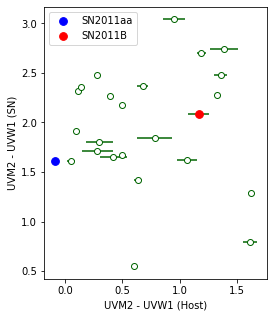

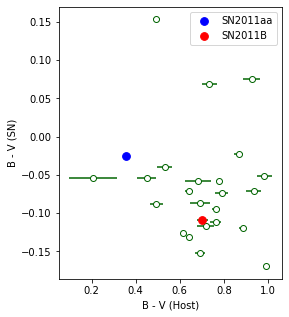

In [26]:
#with Kcorrected ones - seperateing based on color Host vs SN

#making same size
#K_sn_names = K_df.loc[:,'sn']   
#SN_sn_names = SN_df.loc[:,'sn'] 

#get the shared SN names
common_sn = np.intersect1d(K_df['sn'], SN_df['sn'])

#only include those SN
K_matched = K_df[K_df['sn'].isin(common_sn)].reset_index(drop=True)
SN_matched = SN_df[SN_df['sn'].isin(common_sn)].reset_index(drop=True)

K_x2 = K_matched['K_UVM2'] - K_matched['K_UVW1']
K_y2 = K_matched['K_B'] - K_matched['K_V']
K_x2err = abs(K_matched['Kerr_UVM2'] - K_matched['Kerr_UVW1'])
K_y2err = abs(K_matched['Kerr_B'] - K_matched['Kerr_V'])

SN_x2 = SN_matched['SN_UVM2'] - SN_matched['SN_UVW1']
SN_y2 = SN_matched['SN_B'] - SN_matched['SN_V']

# Find their index in K_matched
i_aa = K_matched[K_matched['sn'] == 'SN2011aa'].index[0]
i_B  = K_matched[K_matched['sn'] == 'SN2011B'].index[0]

#K_x2 = K_UVM2-K_UVW1
#K_y2 = K_B-K_V
#K_x2err = abs(Kerr_UVM2-Kerr_UVW1)
#K_y2err = abs(Kerr_B-Kerr_V)

#sn
#SN_x2 = SN_UVM2-SN_UVW1
#SN_y2 = SN_B-SN_V

#plot
plt.figure(figsize=(4,5))
plt.tight_layout()
plt.xlabel('UVM2 - UVW1 (Host)')
plt.ylabel('UVM2 - UVW1 (SN)')
#plt.scatter(x2,y)
plt.errorbar(K_x2,SN_x2, xerr=K_x2err, fmt='o', ecolor='darkgreen', mfc='white',mec='darkgreen')
#plt.errorbar(x2_good,y2_good, xerr=x2err_good, yerr=y2err_good, fmt='o', ecolor='k', mfc='white',mec='k')
#plt.xlim(-3,0.5)
#plt.ylim(-0.5,1.18)
#plt.scatter(x=0.088, y=0.368, color='blue', s=60, zorder=10)
#plt.scatter(x= -0.088, y=-0.636229, marker='x', color='blue', s=60, zorder=10, label='SN2011aa')
#plt.scatter(x=-1.166, y=0.702, color='red', s=60, zorder=10)
#plt.scatter(x=1.166, y=-2.078456, marker='x', color='red', s=60, zorder=10, label='SN2011B')
plt.scatter(K_x2[i_aa], SN_x2[i_aa], marker='o', color='blue', s=60, label='SN2011aa', zorder=10)
plt.scatter(K_x2[i_B],  SN_x2[i_B],  marker='o', color='red', s=60, label='SN2011B', zorder=10)
plt.legend()

#plt.savefig('K_SN_M2-W1')
plt.show()
plt.close()

plt.figure(figsize=(4,5))
plt.tight_layout()
plt.xlabel('B - V (Host)')
plt.ylabel('B - V (SN)')
#plt.scatter(x2,y)
plt.errorbar(K_y2,SN_y2, xerr=K_y2err, fmt='o', ecolor='darkgreen', mfc='white',mec='darkgreen')
#plt.errorbar(x2_good,y2_good, xerr=x2err_good, yerr=y2err_good, fmt='o', ecolor='k', mfc='white',mec='k')
#plt.xlim(-3,0.5)
#plt.ylim(-0.5,1.18)
#plt.scatter(x=0.088, y=0.368, color='blue', s=60, zorder=10)
#plt.scatter(x= 0.368, y=-0.111103, marker='x', color='blue', s=60, zorder=10, label='SN2011aa')
#plt.scatter(x=-1.166, y=0.702, color='red', s=60, zorder=10)
#plt.scatter(x=0.702, y=-0.033755, marker='x', color='red', s=60, zorder=10, label='SN2011B')
plt.scatter(K_y2[i_aa], SN_y2[i_aa], marker='o', color='blue', s=60, label='SN2011aa', zorder=10)
plt.scatter(K_y2[i_B],  SN_y2[i_B],  marker='o', color='red', s=60, label='SN2011B', zorder=10)
plt.legend()

#plt.savefig('K_SN_B-V')
plt.show()
plt.close()

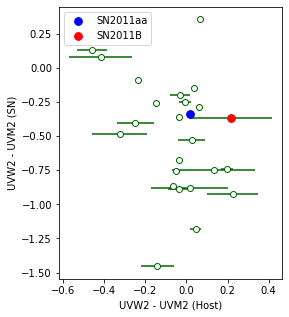

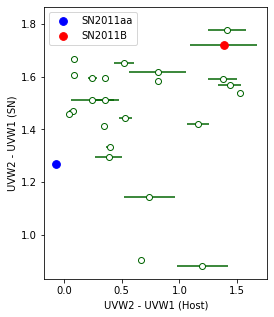

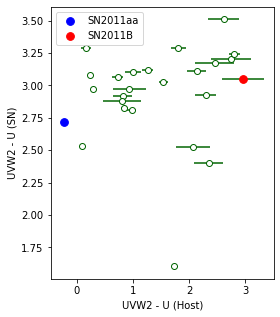

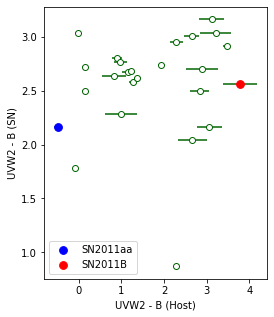

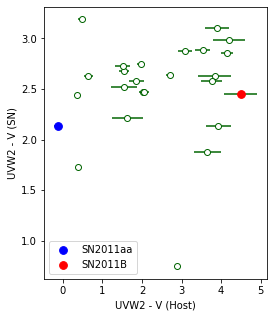

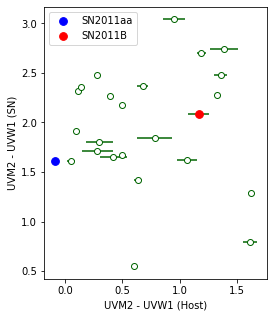

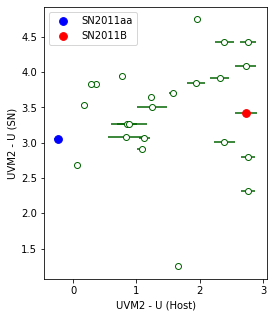

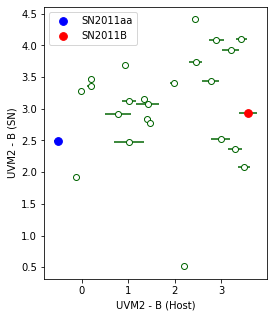

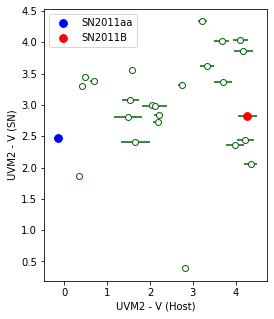

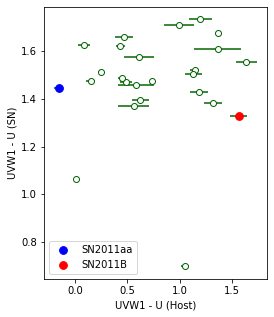

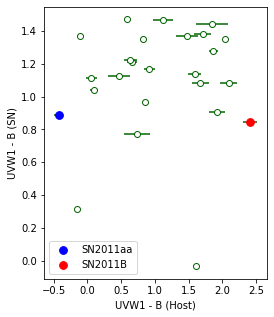

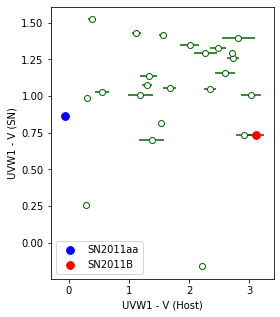

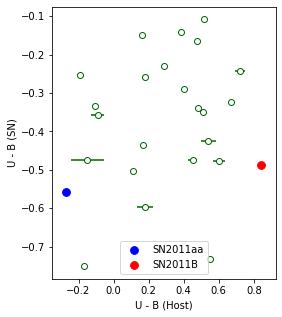

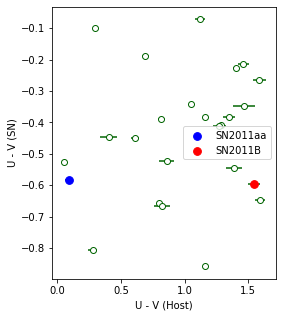

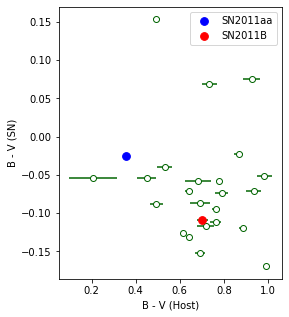

In [27]:
#multistat some approach
#opt

#get the shared SN names
common_sn = np.intersect1d(K_df['sn'], SN_df['sn'])

#only include those SN
K_matched = K_df[K_df['sn'].isin(common_sn)].reset_index(drop=True)
SN_matched = SN_df[SN_df['sn'].isin(common_sn)].reset_index(drop=True)

filters = ['UVW2', 'UVM2', 'UVW1', 'U', 'B', 'V']

for fil1, fil2 in itertools.combinations(filters, 2):
    
    K_x = K_matched[f'K_{fil1}'] - K_matched[f'K_{fil2}']
    K_xerr = abs(K_matched[f'Kerr_{fil1}'] - K_matched[f'Kerr_{fil2}'])
    SN_y = SN_matched[f'SN_{fil1}'] - SN_matched[f'SN_{fil2}']

    # Find their index in K_matched
    i_aa = K_matched[K_matched['sn'] == 'SN2011aa'].index[0]
    i_B  = K_matched[K_matched['sn'] == 'SN2011B'].index[0]

    #plot
    plt.figure(figsize=(4,5))
    plt.tight_layout()
    plt.xlabel(f'{fil1} - {fil2} (Host)')
    plt.ylabel(f'{fil1} - {fil2} (SN)')
    plt.errorbar(K_x,SN_y, xerr=K_xerr, fmt='o', ecolor='darkgreen', mfc='white',mec='darkgreen')
    plt.scatter(K_x[i_aa], SN_y[i_aa], marker='o', color='blue', s=60, label='SN2011aa', zorder=10)
    plt.scatter(K_x[i_B],  SN_y[i_B],  marker='o', color='red', s=60, label='SN2011B', zorder=10)
    plt.legend()

    plt.savefig(f'plots/{fil1}vs{fil2}')
    plt.show()
    plt.close()

# goal: color vs mag graph of sn = (uvw2 - v) vs v
- shows the widest range of colors
- using observed mags
- best contrast to find more blue and red galaxies

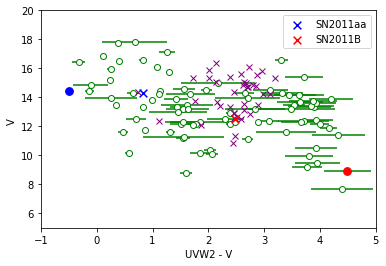

In [28]:
#saving rel variables: 
K_x3 = K_UVW2-K_V
K_y3 = K_V
K_x3err = abs(Kerr_UVW2-Kerr_V)
K_y3err = abs(Kerr_V)

SN_x3 = SN_UVW2-SN_V
SN_y3 = SN_V

#plot
plt.figure()
plt.tight_layout()
plt.xlabel('UVW2 - V')
plt.ylabel('V ')
#plt.scatter(x3,y3)
plt.errorbar(K_x3,K_y3, xerr=K_x3err, yerr=K_y3err, fmt='o', ecolor='green', mfc='white',mec='green')
plt.errorbar(SN_x3,SN_y3, fmt='x', ecolor='purple', mfc='purple',mec='purple')
#plt.scatter(x=-1.89, y=20.676, color='blue', s=60, zorder=10, label='ASASSN-15rw')
#plt.scatter(x=1.316, y=11.609, color='yellow', s=60, zorder=10, label='17')
plt.scatter(x=-0.497, y=14.403253, color='blue', s=60, zorder=10)
plt.scatter(x=0.820645, y=14.298304, marker='x', color='blue', s=60, zorder=10, label='SN2011aa')
plt.scatter(x=4.493, y=8.89594151, color='red', s=60, zorder=10)
plt.scatter(x=2.486329, y=12.503078, marker='x', color='red', s=60, zorder=10, label='SN2011B')
plt.xlim(-1,5)
plt.ylim(5,20)

plt.legend()
plt.savefig('K_SN_ColorvMag')
plt.show()
plt.close()


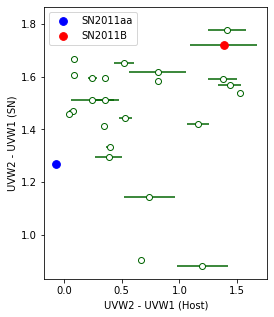

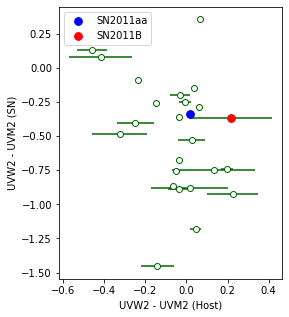

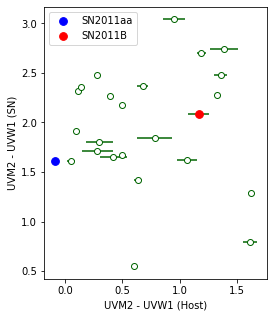

In [30]:
#for poster

#get the shared SN names
common_sn = np.intersect1d(K_df['sn'], SN_df['sn'])

#only include those SN
K_matched = K_df[K_df['sn'].isin(common_sn)].reset_index(drop=True)
SN_matched = SN_df[SN_df['sn'].isin(common_sn)].reset_index(drop=True)

K_x2 = K_matched['K_UVW2'] - K_matched['K_UVW1']
K_y2 = K_matched['K_UVW2'] - K_matched['K_UVM2']
K_z2 = K_matched['K_UVM2'] - K_matched['K_UVW1']
K_x2err = abs(K_matched['Kerr_UVW2'] - K_matched['Kerr_UVW1'])
K_y2err = abs(K_matched['Kerr_UVW2'] - K_matched['Kerr_UVM2'])
K_z2err = abs(K_matched['Kerr_UVM2'] - K_matched['Kerr_UVW1'])

SN_x2 = SN_matched['SN_UVW2'] - SN_matched['SN_UVW1']
SN_y2 = SN_matched['SN_UVW2'] - SN_matched['SN_UVM2']
SN_z2 = SN_matched['SN_UVM2'] - SN_matched['SN_UVW1']

# Find their index in K_matched
i_aa = K_matched[K_matched['sn'] == 'SN2011aa'].index[0]
i_B  = K_matched[K_matched['sn'] == 'SN2011B'].index[0]

#plot
plt.figure(figsize=(4,5))
plt.tight_layout()
plt.xlabel('UVW2 - UVW1 (Host)')
plt.ylabel('UVW2 - UVW1 (SN)')
plt.errorbar(K_x2,SN_x2, xerr=K_x2err, fmt='o', ecolor='darkgreen', mfc='white',mec='darkgreen')
plt.scatter(K_x2[i_aa], SN_x2[i_aa], marker='o', color='blue', s=60, label='SN2011aa', zorder=10)
plt.scatter(K_x2[i_B],  SN_x2[i_B],  marker='o', color='red', s=60, label='SN2011B', zorder=10)
plt.legend()

#plt.savefig('K_SN_M2-W1')
plt.show()
plt.close()

plt.figure(figsize=(4,5))
plt.tight_layout()
plt.xlabel('UVW2 - UVM2 (Host)')
plt.ylabel('UVW2 - UVM2 (SN)')
plt.errorbar(K_y2,SN_y2, xerr=K_y2err, fmt='o', ecolor='darkgreen', mfc='white',mec='darkgreen')
plt.scatter(K_y2[i_aa], SN_y2[i_aa], marker='o', color='blue', s=60, label='SN2011aa', zorder=10)
plt.scatter(K_y2[i_B],  SN_y2[i_B],  marker='o', color='red', s=60, label='SN2011B', zorder=10)
plt.legend()

#plt.savefig('K_SN_B-V')
plt.show()
plt.close()

plt.figure(figsize=(4,5))
plt.tight_layout()
plt.xlabel('UVM2 - UVW1 (Host)')
plt.ylabel('UVM2 - UVW1 (SN)')
plt.errorbar(K_z2,SN_z2, xerr=K_z2err, fmt='o', ecolor='darkgreen', mfc='white',mec='darkgreen')
plt.scatter(K_z2[i_aa], SN_z2[i_aa], marker='o', color='blue', s=60, label='SN2011aa', zorder=10)
plt.scatter(K_z2[i_B],  SN_z2[i_B],  marker='o', color='red', s=60, label='SN2011B', zorder=10)
plt.legend()

#plt.savefig('K_SN_B-V')
plt.show()
plt.close()